<div style="background:linear-gradient(135deg,#172554 0%,#1e40af 55%,#3b82f6 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#bfdbfe;font-weight:700;text-transform:uppercase">Chapter 69 · Estimation &amp; Confidence Intervals</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Point vs. Interval Estimation 🎯</div>
  <div style="font-size:15px;color:#eff6ff;max-width:740px;line-height:1.6">A point estimate is a single best guess; an interval estimate wraps that guess in honest uncertainty. We watch point estimates wobble from sample to sample, then build an interval that captures the truth a known fraction of the time, and finish on a real home-sales spreadsheet.</div>
  <div style="margin-top:16px;font-size:13px;color:#bfdbfe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
BLUE="#2563eb"; DEEP="#1d4ed8"; LIGHT="#60a5fa"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
rng = np.random.default_rng(69)

<div style="background:#eef2ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">BEAT 1 · A POINT ESTIMATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">One number as our best guess</div>
<div style="color:#4a5578;margin-top:6px">A point estimate is a single statistic, like the sample mean, used to estimate an unknown population parameter. We build a population with a known mean of 100, draw one sample of 40, and read off the point estimate.</div>
</div>

In [2]:
POP = rng.normal(100, 18, 500_000)   # unknown-in-practice population, true mean = 100
MU = POP.mean()
sample = rng.choice(POP, 40, replace=False)
point = sample.mean()
print(f"true population mean (mu) = {MU:.2f}  (unknown in real life)")
print(f"point estimate from one sample of 40: x-bar = {point:.2f}")
print(f"off by {point-MU:+.2f}")

true population mean (mu) = 99.97  (unknown in real life)
point estimate from one sample of 40: x-bar = 101.64
off by +1.67


The sample mean **x&#772;** is our single best guess for &#956;. It is close, but it is one number with no sense of how far off it might be. The honest question is: how much would this guess change if we had drawn a different sample?

<div style="background:#eef2ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">BEAT 2 · POINT ESTIMATES WOBBLE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The same recipe, a different number each time</div>
<div style="color:#4a5578;margin-top:6px">An estimator is a random variable: every fresh sample gives a different point estimate. The spread of those estimates is the standard error, SE = sigma/sqrt(n). This wobble is exactly what an interval has to capture.</div>
</div>

5000 point estimates: average 99.97 (centered on mu=99.97), spread (SE) 2.84
formula SE = sigma/sqrt(n) = 2.84


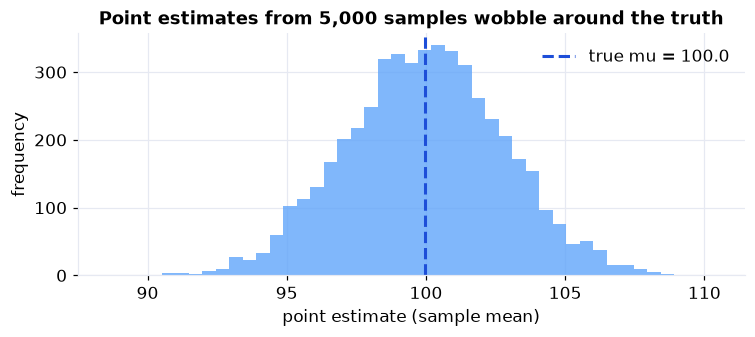

In [3]:
points = np.array([rng.choice(POP, 40, replace=False).mean() for _ in range(5000)])
print(f"5000 point estimates: average {points.mean():.2f} (centered on mu={MU:.2f}), spread (SE) {points.std():.2f}")
print(f"formula SE = sigma/sqrt(n) = {POP.std()/np.sqrt(40):.2f}")
fig,ax=plt.subplots(figsize=(7,3.2))
ax.hist(points, bins=45, color=LIGHT, alpha=0.8)
ax.axvline(MU, color=DEEP, ls="--", lw=2, label=f"true mu = {MU:.1f}")
ax.set_xlabel("point estimate (sample mean)"); ax.set_ylabel("frequency")
ax.set_title("Point estimates from 5,000 samples wobble around the truth"); ax.legend()
plt.tight_layout(); plt.show()

The point estimates form a tight bell centered on the true mean, with a standard deviation equal to the **standard error**. A single point estimate is one draw from this bell, so it is almost never exactly right. An <em>interval</em> estimate turns that spread into a stated range.

<div style="background:#eef2ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">BEAT 3 · AN INTERVAL ESTIMATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Best guess, plus or minus a margin</div>
<div style="color:#4a5578;margin-top:6px">An interval estimate is point estimate +/- margin, where the margin = z * SE. A 95% interval is built so that, over many samples, about 95% of the intervals contain the true parameter. We draw 100 intervals and count.</div>
</div>

of 100 intervals, 96 contain the true mean 100.0  (target ~95)


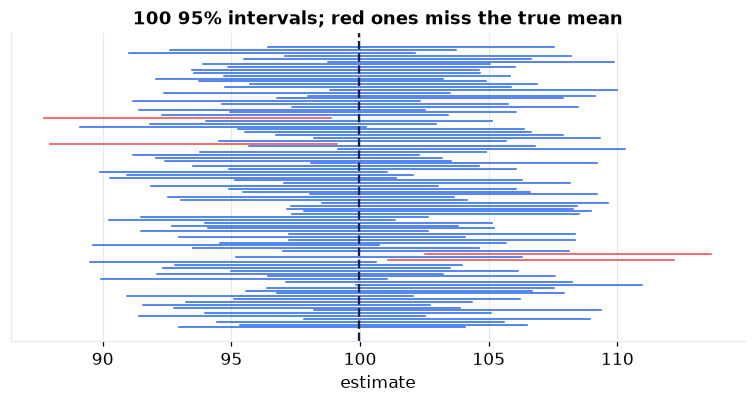

In [4]:
z = stats.norm.ppf(0.975)            # 1.96
sigma = POP.std()
def interval(n=40):
    s = rng.choice(POP, n, replace=False); xb = s.mean(); se = sigma/np.sqrt(n)
    return xb - z*se, xb + z*se, xb
lo, hi, mid = np.array([interval() for _ in range(100)]).T
covers = (lo <= MU) & (MU <= hi)
print(f"of 100 intervals, {covers.sum()} contain the true mean {MU:.1f}  (target ~95)")
fig,ax=plt.subplots(figsize=(7,3.8))
for i in range(100):
    ax.plot([lo[i],hi[i]],[i,i], color=(BLUE if covers[i] else "#ef4444"), lw=1)
ax.axvline(MU, color=INK, ls="--", lw=1.5)
ax.set_yticks([]); ax.set_xlabel("estimate"); ax.set_title("100 95% intervals; red ones miss the true mean")
plt.tight_layout(); plt.show()

About 95 of the 100 intervals capture the true mean; the few red misses are the price of 95% (not 100%) confidence. This is the meaning of "95% confident": it is a property of the <em>procedure</em> over many samples, not a probability about one fixed interval. The interval is wider than a point, and that width is its honesty.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">REAL-WORLD EXAMPLE · HOME SALES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Estimating the average sale price in a market</div>
<div style="color:#4a5578;margin-top:6px"></div>
</div>

We load a spreadsheet of **220 closed home sales** (`ch69_home_sales.xlsx`), the kind of export an assessor or MLS produces. We do not know the true average price of all homes in this market, so we **estimate** it: a point estimate plus a 95% interval.

In [5]:
try:    homes = pd.read_excel("../../data/ch69_home_sales.xlsx", sheet_name="Sales")
except FileNotFoundError: homes = pd.read_excel(BASE+"ch69_home_sales.xlsx", sheet_name="Sales")
print("loaded:", homes.shape)
homes[["sale_id","neighborhood","sale_price","sqft","bedrooms"]].head()

loaded: (220, 9)


,sale_id,neighborhood,sale_price,sqft,bedrooms
0,H4000,Oak Hill,268900,1105,1
1,H4001,Oak Hill,350600,2057,3
2,H4002,Lakeview,281900,1475,3
3,H4003,Downtown,329700,1927,3
4,H4004,Riverside,351900,1711,4


In [6]:
price = homes["sale_price"]
n = len(price); xbar = price.mean(); s = price.std(ddof=1); se = s/np.sqrt(n)
z = stats.norm.ppf(0.975)
lo, hi = xbar - z*se, xbar + z*se
print(f"n = {n} sales")
print(f"POINT estimate of mean sale price: ${xbar:,.0f}")
print(f"std dev ${s:,.0f}  ->  standard error ${se:,.0f}")
print(f"INTERVAL estimate (95%): ${lo:,.0f}  to  ${hi:,.0f}   (= ${xbar:,.0f} +/- ${z*se:,.0f})")
print(f"\nmedian sale price ${price.median():,.0f}  (mean > median signals right skew)")

n = 220 sales
POINT estimate of mean sale price: $338,159
std dev $69,417  ->  standard error $4,680
INTERVAL estimate (95%): $328,986  to  $347,331   (= $338,159 +/- $9,173)

median sale price $335,550  (mean > median signals right skew)


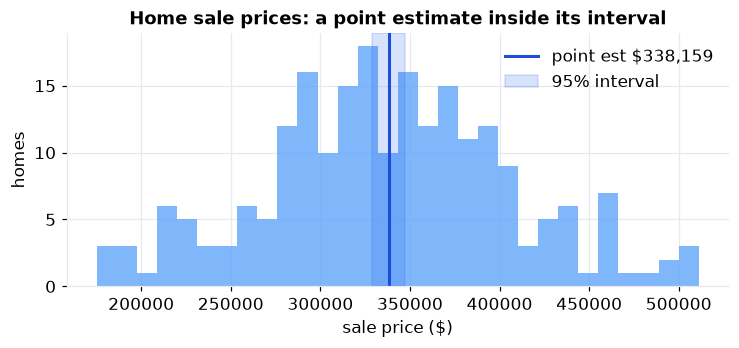

In [7]:
fig,ax=plt.subplots(figsize=(7,3.3))
ax.hist(price, bins=30, color=LIGHT, alpha=0.8)
ax.axvline(xbar, color=DEEP, lw=2, label=f"point est ${xbar:,.0f}")
ax.axvspan(lo, hi, color=BLUE, alpha=0.18, label="95% interval")
ax.set_xlabel("sale price ($)"); ax.set_ylabel("homes"); ax.set_title("Home sale prices: a point estimate inside its interval"); ax.legend()
plt.tight_layout(); plt.show()

The point estimate of the average sale price is about **$338,000**, and the 95% interval runs roughly **$329,000 to $347,000**. Reporting only the point would hide the uncertainty; the interval says, honestly, "the market average is very likely in this band." Because prices are right-skewed (mean above median), the next chapters will also show when the median or the bootstrap is the better tool.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ Point vs. interval</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">A point estimate is a single best guess; because it wobbles from sample to sample by an amount called the standard error, an honest answer reports an interval, the point plus or minus a margin. A 95% interval is built so the procedure captures the truth about 95% of the time. On real home-sales data the average price is a point of ~$338k inside a 95% interval of about $329k to $347k. The next chapters build these intervals precisely.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>